<a href="https://colab.research.google.com/github/Subho7439/diabetes_prediction_system_dl/blob/main/diabetis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
df = pd.read_csv("diabetes.csv")
print(df.head(3))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  


In [13]:
#CHECKING MISSING VALUE

is_null = df.isnull().sum().sum()

if is_null == 0 :
  print("no missing value present")

no missing value present


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   639.000000  639.000000     639.000000     639.000000  639.000000   
mean      3.804382  119.112676      72.120501      20.563380   65.931142   
std       3.260995   29.162175      11.348686      15.339991   79.569482   
min       0.000000   44.000000      38.000000       0.000000    0.000000   
25%       1.000000   99.000000      64.000000       0.000000    0.000000   
50%       3.000000  114.000000      72.000000      23.000000   37.000000   
75%       6.000000  137.000000      80.000000      32.000000  120.000000   
max      13.000000  198.000000     106.000000      60.000000  318.000000   

             BMI  DiabetesPedigreeFunction         Age     Outcome  
count  639.00000                639.000000  639.000000  639.000000  
mean    32.00579                  0.429177   32.715180    0.312989  
std      6.43397                  0.250957   11.080651    0.464073  
min     18.20000                  0.078

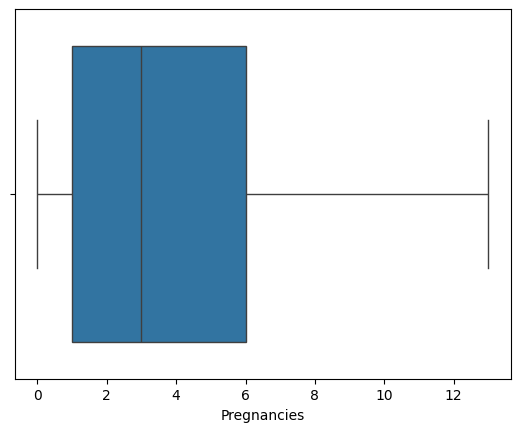

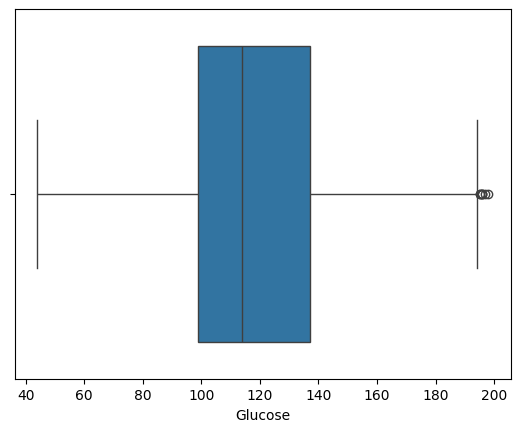

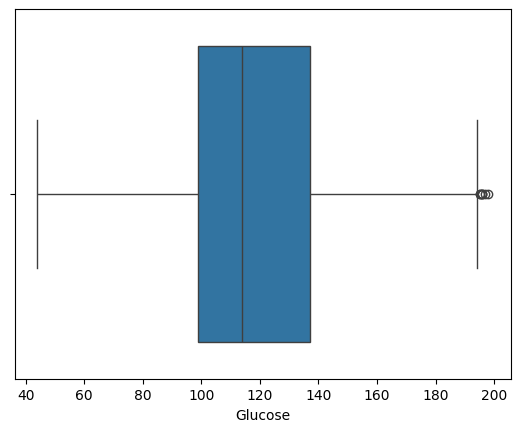

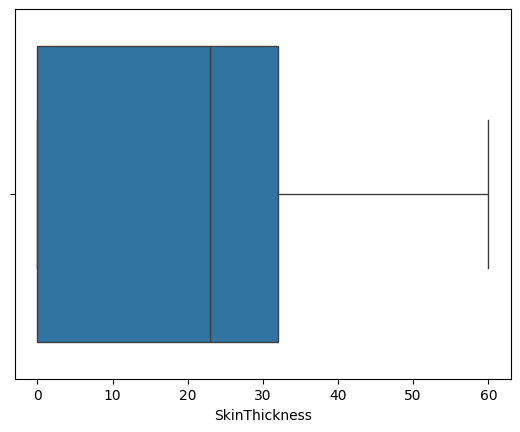

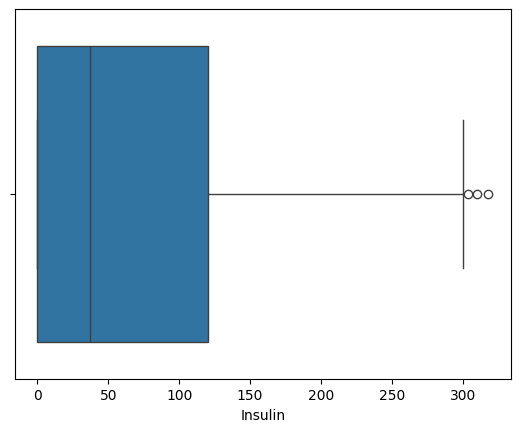

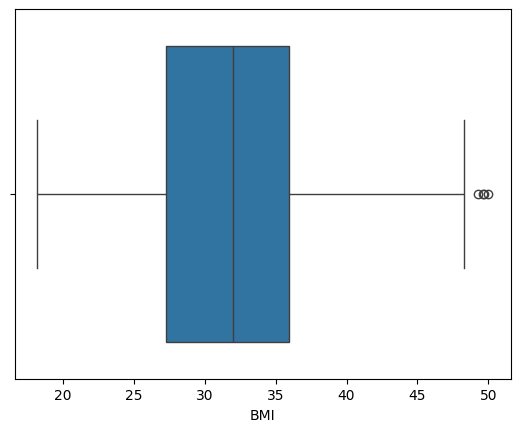

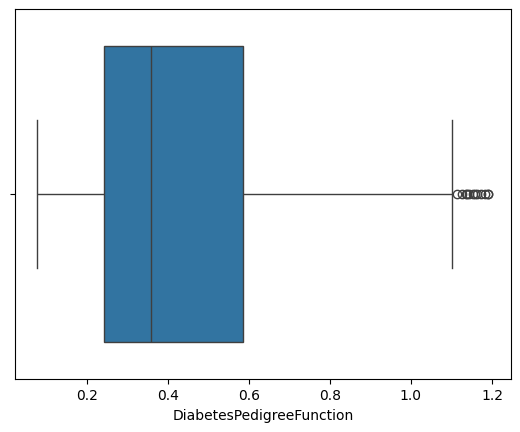

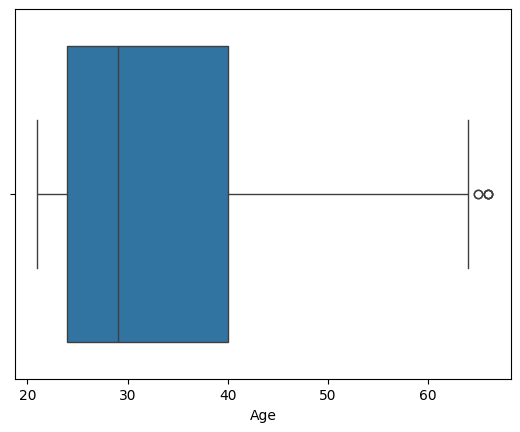

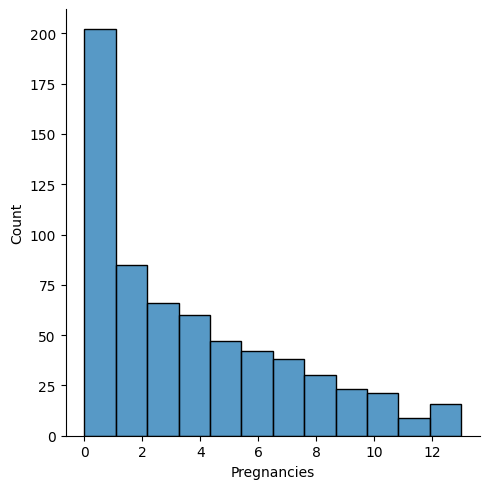

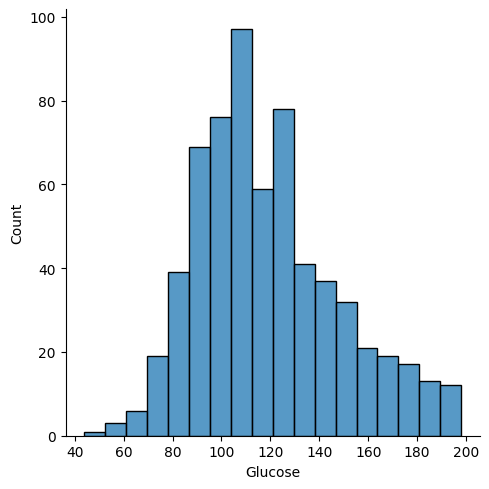

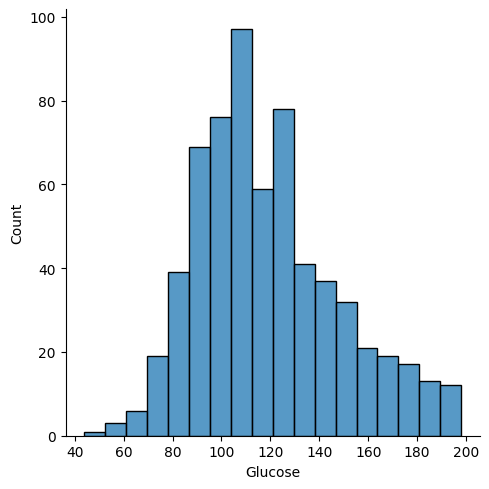

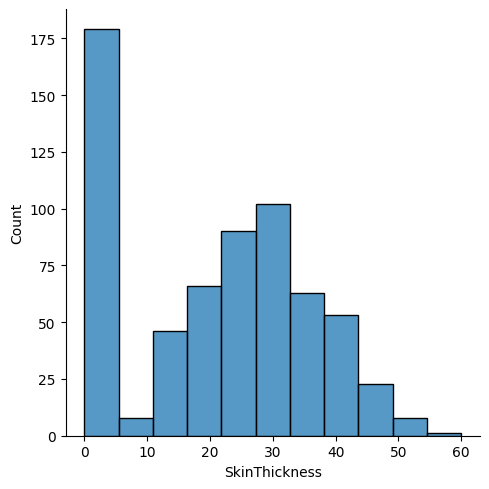

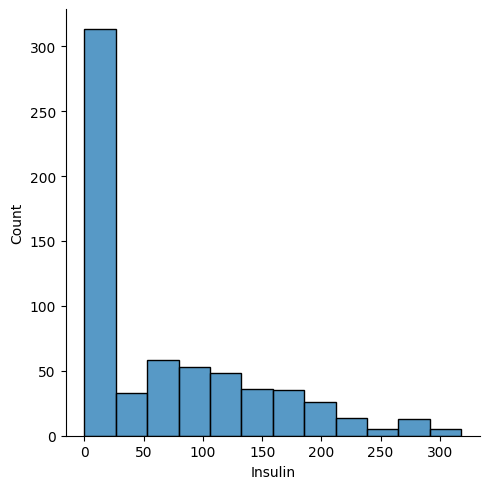

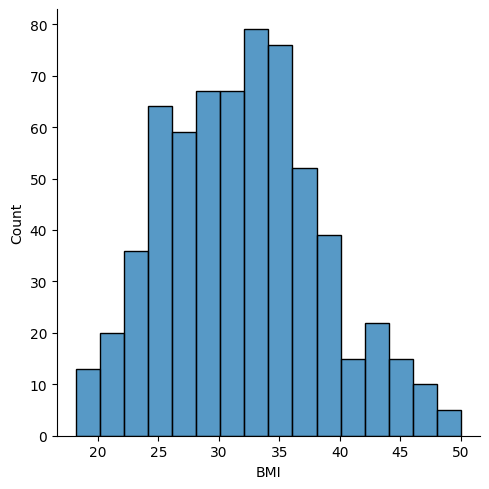

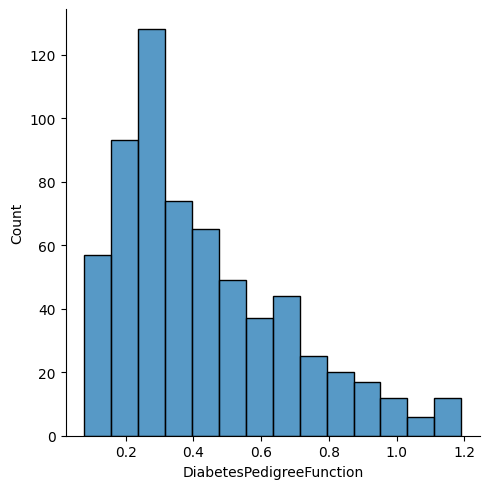

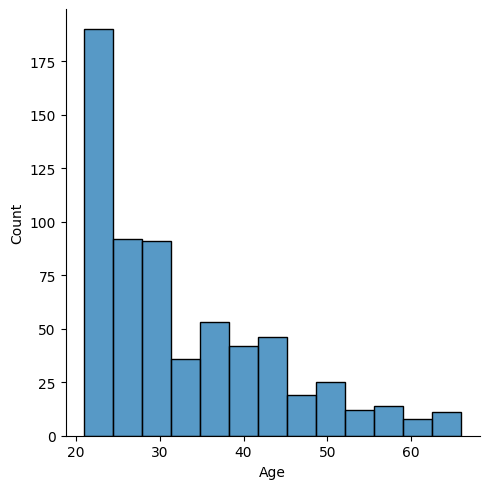

before handlingoutlier : 
(639, 9)
after handlingoutlier : 
(598, 9)


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#CHECKING OUTLIER

print(df.describe())

df1 = df[["Pregnancies","Glucose","Glucose","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]]
for i in df1.columns:
  sns.boxplot(x=i,data=df)
  plt.show()
for i in df1.columns:
  sns.displot(x=i,data=df)
  plt.show()

print("before handlingoutlier : ")
print(df.shape)

#HANDLING OUTLIER

q3 = df.iloc[:,:-1].quantile(0.75)
q1 = df.iloc[:,:-1].quantile(0.25)
iqr = q3 - q1
uo = q3 + 1.5 * iqr
lo = q1 - 1.5 * iqr


inlier_mask = (df.iloc[:,:-1] > lo) & (df.iloc[:,:-1] < uo)
df = df[inlier_mask.all(axis=1)]

print("after handlingoutlier : ")
print(df.shape)

In [25]:
#ENCODING

print(df.info())

#NO LABEL ENCODING REQUIRE

<class 'pandas.core.frame.DataFrame'>
Index: 598 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               598 non-null    int64  
 1   Glucose                   598 non-null    int64  
 2   BloodPressure             598 non-null    int64  
 3   SkinThickness             598 non-null    int64  
 4   Insulin                   598 non-null    int64  
 5   BMI                       598 non-null    float64
 6   DiabetesPedigreeFunction  598 non-null    float64
 7   Age                       598 non-null    int64  
 8   Outcome                   598 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 46.7 KB
None


In [29]:
#DUPLICATE DATA

dupli = (df.duplicated().sum().sum())
if dupli == 0 :
  print("no duplicate data present")

no duplicate data present


In [92]:
#FEATURE SCALLING

from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()
df.iloc[:,:-1] = ms.fit_transform(df.iloc[:,:-1])
print(df.describe())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   598.000000  598.000000     598.000000     598.000000  598.000000   
mean      0.285953    0.487800       0.475522       0.343060    0.218544   
std       0.247998    0.182199       0.187241       0.253365    0.258973   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       0.076923    0.357383       0.344828       0.000000    0.000000   
50%       0.230769    0.456376       0.482759       0.383333    0.136519   
75%       0.461538    0.595638       0.612069       0.533333    0.392491   
max       1.000000    1.000000       1.000000       1.000000    1.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  598.000000                598.000000  598.000000  598.000000  
mean     0.451455                  0.330939    0.259994    0.287625  
std      0.208846                  0.226895    0.248046    0.453034  
min      0.000000                  

In [45]:
#CHECKING IMBALANCE DATA
from sklearn.model_selection import train_test_split
print(df["Outcome"].value_counts())

from imblearn.under_sampling import RandomUnderSampler
ru = RandomUnderSampler()
x = df.iloc[:,:-1]
y = df["Outcome"]

ru_x,ru_y = ru.fit_resample(x,y)
print(ru_y.value_counts())
x_train,x_test,y_train,y_test = train_test_split(ru_x,ru_y,test_size=0.2,random_state=42)

Outcome
0    426
1    172
Name: count, dtype: int64
Outcome
0    172
1    172
Name: count, dtype: int64


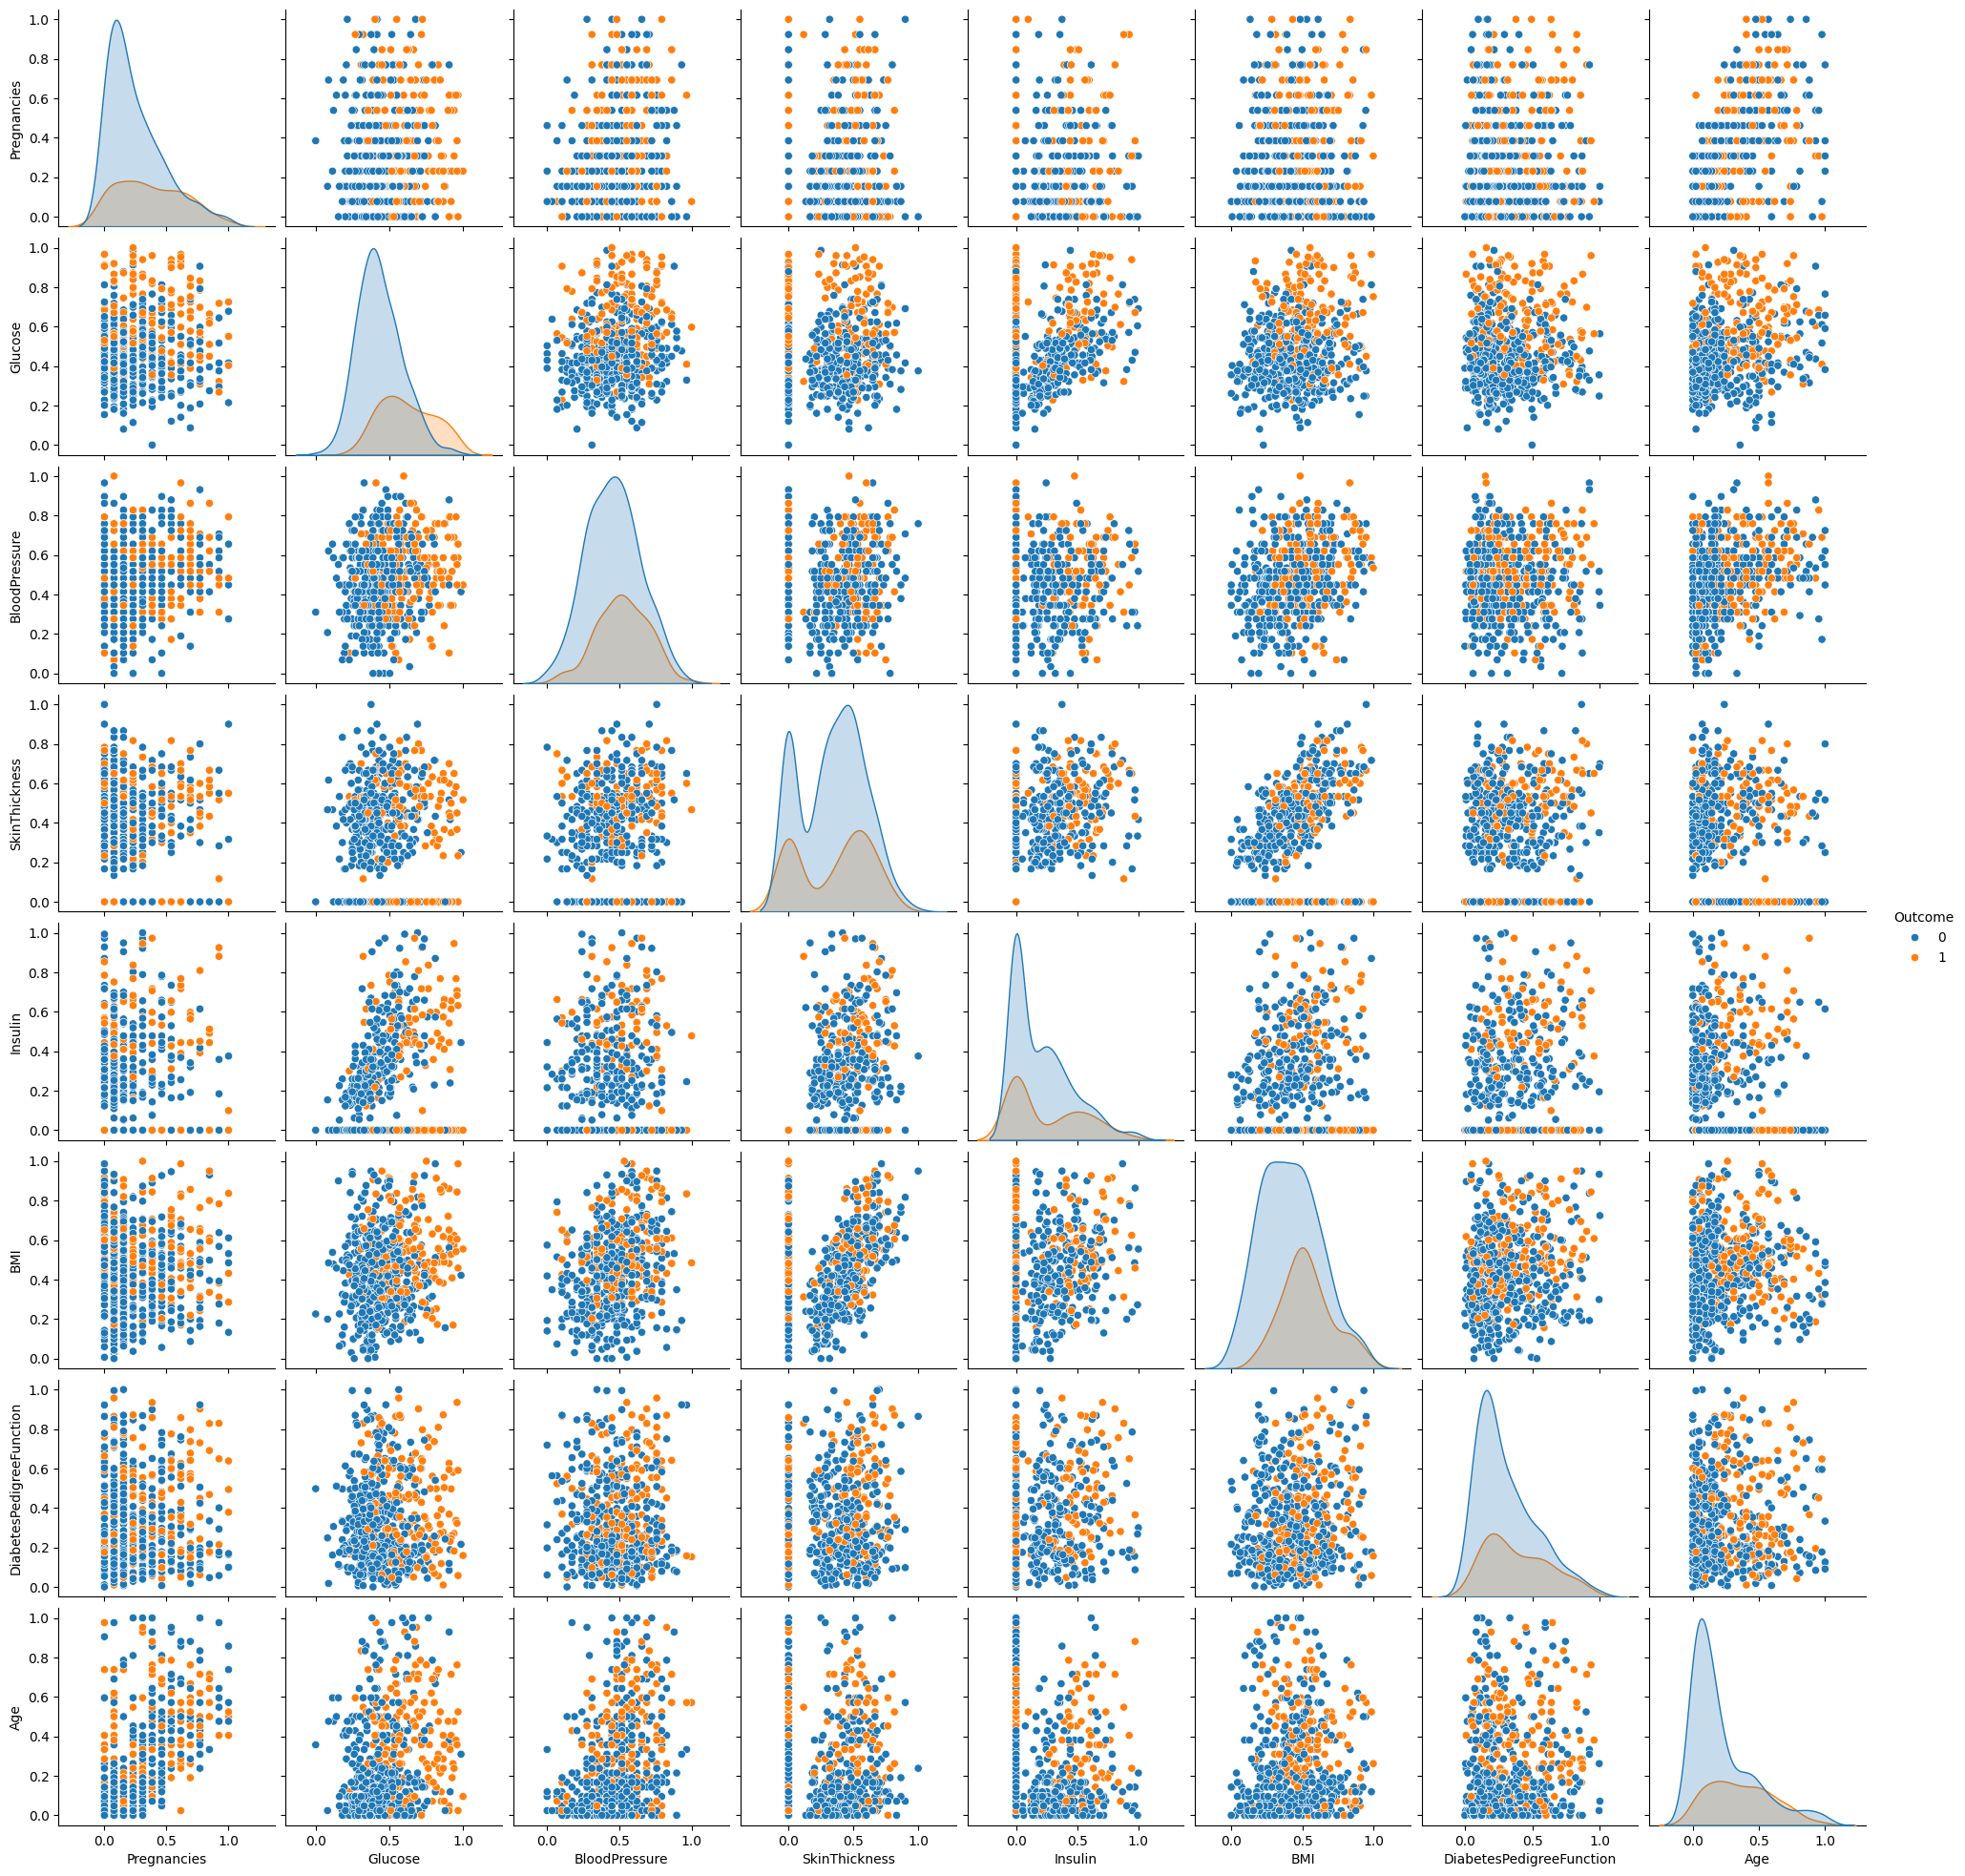

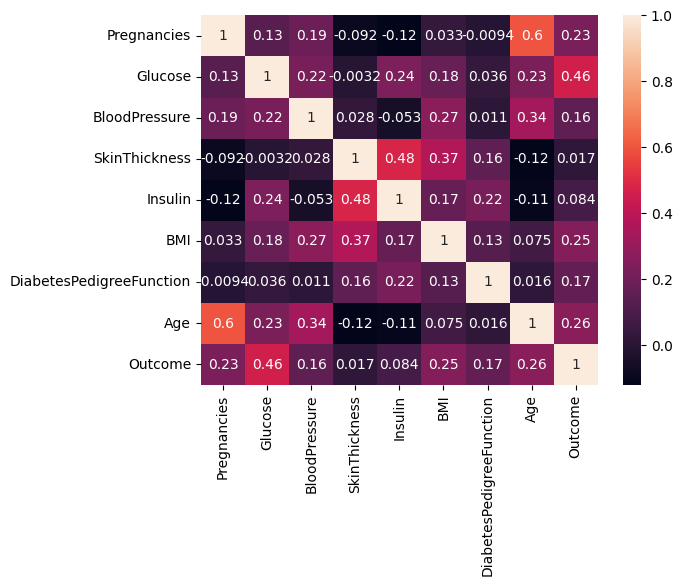

In [66]:
#EDA

sns.pairplot(data=df,hue="Outcome")
plt.show()
sns.heatmap(data=df.corr(),annot=True)
plt.show()

In [83]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.regularizers import L2
from keras.callbacks import EarlyStopping

ann = Sequential()
ann.add(Dense(32,input_dim = 8,activation="relu",kernel_regularizer=L2(l2 = 0.01)))
ann.add(Dropout(0.2))
ann.add(Dense(16,activation="relu"))
ann.add(Dropout(0.2))
ann.add(Dense(8,activation="relu"))
ann.add(Dropout(0.2))
ann.add(Dense(1,activation="sigmoid"))
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
ann.fit(x_train,y_train,epochs=100,batch_size=32,callbacks=EarlyStopping(patience=10))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5527 - loss: 0.8170
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5382 - loss: 0.8118 
Epoch 3/100


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 0.8151
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5236 - loss: 0.7959
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5855 - loss: 0.7922
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6036 - loss: 0.7844
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6000 - loss: 0.7735 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5927 - loss: 0.7740 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5818 - loss: 0.7729 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6145 - loss: 0.7581
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5782 - loss: 0.7596 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5418 - loss: 0.7552 
Epoch 13/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6364 - loss: 0.7465 
Epoch 14/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6109 - loss: 0.7394

In [84]:
ann.evaluate(x_test,y_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7536 - loss: 0.5600 


[0.5600059032440186, 0.7536231875419617]

In [86]:
from sklearn.metrics import accuracy_score
l = ann.predict(x_test)
predict=[]
for i in l:
  if i[0] > 0.5:
    predict.append(1)
  else:
    predict.append(0)

print(accuracy_score(y_test,predict))

l1 = ann.predict(x_train)
predict1=[]
for i in l1:
  if i[0] > 0.5:
    predict1.append(1)
  else:
    predict1.append(0)

print(accuracy_score(y_train,predict1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
0.7536231884057971
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
0.7818181818181819


In [95]:
import numpy as np
test=[6,148,72,35,0,33.6,0.627,50]

test_array = np.array(test).reshape(1, -1)


test_scaled = ms.transform(test_array)


predict = ann.predict(test_scaled)


if predict[0][0]>0.5:
  print("Diabetic")
else:
  print("Non Diabetic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


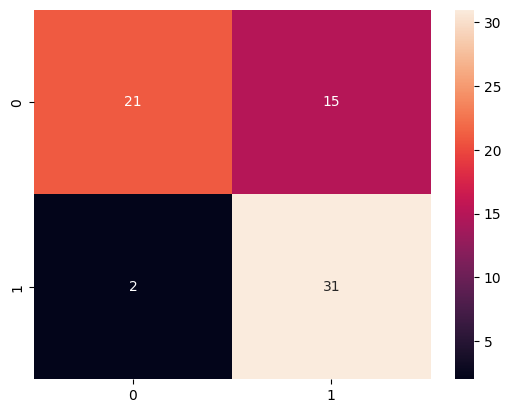

recall :  93.93939393939394
precision :  67.3913043478261
f1_score :  78.48101265822784


In [99]:
from sklearn.metrics import confusion_matrix,recall_score,precision_score,f1_score
g = ann.predict(x_test)
pred=[]
for i in g:
  if i[0] > 0.5:
    pred.append(1)
  else:
    pred.append(0)

cm = confusion_matrix(y_test,pred)
sns.heatmap(data = cm,annot = True)
plt.show()
print("recall : ",recall_score(y_test,pred)*100)
print("precision : ",precision_score(y_test,pred)*100)
print("f1_score : ",f1_score(y_test,pred)*100)